In [1]:
import re
from collections import defaultdict
from pathlib import Path
from typing import Dict, List

import pandas as pd

DATA = Path("clean_perfume_data.csv") 
OUT_DIR = Path("results"); OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_ENRICHED = OUT_DIR / "enriched_perfume_data.csv"
OUT_SCORES = OUT_DIR / "season_gender_keyword_scores.csv"

pd.set_option("display.max_colwidth", 160)
print("Paths OK:", DATA.resolve(), "->", OUT_DIR.resolve())

Paths OK: C:\Users\jsrin\clean_perfume_data.csv -> C:\Users\jsrin\results


In [3]:
df = pd.read_csv(DATA)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head(5)

Shape: (2191, 6)
Columns: ['Name', 'Brand', 'Description', 'Notes', 'Image URL', 'text_all']


,Name,Brand,Description,Notes,Image URL,text_all
0,Tihota Eau de Parfum,Indult,"Rapa Nui for sugar, Tihota is, quite simply, The One. The One that will call to you every moment you're not smelling it, The One that you've only had hints...","Vanilla bean, musks",https://static.luckyscent.com/images/products/37401.jpg?width=400&404=product.png,indult tihota eau de parfum rapa nui for sugar tihota is quite simply the one the one that will call to you every moment you re not smelling it the one that...
1,Sola Parfum,Di Ser,"A tribute to the expanse of space extending from the sky to the flower and fruit laden earth below, Sola, the newest offering from DI SER and perfumer Yasu...","Lavender, Yuzu, Lemongrass, Magnolia, Geranium, Jasmine, Frankincense, Myrrh",https://static.luckyscent.com/images/products/788011.jpg?width=400&404=product.png,di ser sola parfum a tribute to the expanse of space extending from the sky to the flower and fruit laden earth below sola the newest offering from di ser a...
2,Kagiroi Parfum,Di Ser,"An aromatic ode to the ancient beauty of Japan, Kagiroi represents the changes in the shade of the dawn sky over the mountains of Hokkaido, Japan. As the d...","Green yuzu, green shikuwasa, sansho seed, coriander, ylang-ylang, shiso, rosewood, vetiver, hinoki, cypriol, patchouli, agarwood",https://static.luckyscent.com/images/products/788012.jpg?width=400&404=product.png,di ser kagiroi parfum an aromatic ode to the ancient beauty of japan kagiroi represents the changes in the shade of the dawn sky over the mountains of hokka...
3,Velvet Fantasy Eau de Parfum,Montale,"Velvet Fantasy is a solar fragrance where citrus and velvety fruits mingle with the elegance of rose and the gourmand femininity of violet. Thereafter, inc...","tangerine, pink pepper, black coffee, leather, violet, jasmine, lily of the valley, heliotrope powder, vanilla, amber, sandalwood, toffee, musk,...",https://static.luckyscent.com/images/products/354013.jpg?width=400&404=product.png,montale velvet fantasy eau de parfum velvet fantasy is a solar fragrance where citrus and velvety fruits mingle with the elegance of rose and the gourmand f...
4,A Blvd. Called Sunset Eau de Parfum,A Lab on Fire,"There's no way A Lab On Fire could relocate to Los Angeles and not pay tribute to L.A.'s most iconic Boulevard, home to the legendary neon-drenched rock st...","Bergamot, almond, violet, jasmine, leather, sandalwood, vanilla, tonka",https://static.luckyscent.com/images/products/56719.jpg?width=400&404=product.png,a lab on fire a blvd called sunset eau de parfum there s no way a lab on fire could relocate to los angeles and not pay tribute to l a s most iconic bouleva...


In [5]:
text_cols = ["text_all", "Notes", "Description", "Name", "Brand"]

def combine_text(row):
    parts = []
    for c in text_cols:
        if c in row and pd.notna(row[c]):
            parts.append(str(row[c]))
    return " ".join(parts)

if "text_all" not in df.columns:
    df["text_all"] = df.apply(combine_text, axis=1)

df["text_all"] = df["text_all"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
df.head(3)[["Name","Brand","Notes","Description","text_all"]]

,Name,Brand,Notes,Description,text_all
0,Tihota Eau de Parfum,Indult,"Vanilla bean, musks","Rapa Nui for sugar, Tihota is, quite simply, The One. The One that will call to you every moment you're not smelling it, The One that you've only had hints...",indult tihota eau de parfum rapa nui for sugar tihota is quite simply the one the one that will call to you every moment you re not smelling it the one that...
1,Sola Parfum,Di Ser,"Lavender, Yuzu, Lemongrass, Magnolia, Geranium, Jasmine, Frankincense, Myrrh","A tribute to the expanse of space extending from the sky to the flower and fruit laden earth below, Sola, the newest offering from DI SER and perfumer Yasu...",di ser sola parfum a tribute to the expanse of space extending from the sky to the flower and fruit laden earth below sola the newest offering from di ser a...
2,Kagiroi Parfum,Di Ser,"Green yuzu, green shikuwasa, sansho seed, coriander, ylang-ylang, shiso, rosewood, vetiver, hinoki, cypriol, patchouli, agarwood","An aromatic ode to the ancient beauty of Japan, Kagiroi represents the changes in the shade of the dawn sky over the mountains of Hokkaido, Japan. As the d...",di ser kagiroi parfum an aromatic ode to the ancient beauty of japan kagiroi represents the changes in the shade of the dawn sky over the mountains of hokka...


C:\Users\jsrin\AppData\Local\Temp\ipykernel_17368\699010177.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_brands, x="Count", y="Brand", palette="Spectral")


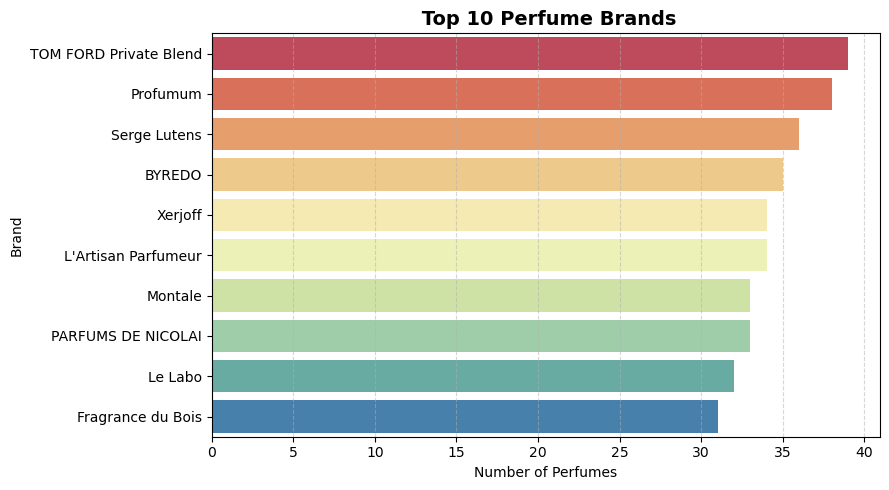

In [9]:
# Top 10 Brands

top_brands = df["Brand"].value_counts().head(10).reset_index()
top_brands.columns = ["Brand", "Count"]

plt.figure(figsize=(9,5))
sns.barplot(data=top_brands, x="Count", y="Brand", palette="Spectral")
plt.title(" Top 10 Perfume Brands", fontsize=14, fontweight="bold")
plt.xlabel("Number of Perfumes")
plt.ylabel("Brand")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [13]:
# --- Prep for notes co-occurrence heatmap ---
import itertools
from collections import Counter

# 1) Make sure the notes column exists; adjust the name if yours differs
NOTES_COL = None
for cand in ["notes", "Notes", "note_list", "notes_clean"]:
    if cand in df.columns:
        NOTES_COL = cand
        break
if NOTES_COL is None:
    raise ValueError("Couldn't find a notes column. Rename one of your columns to 'notes' or set NOTES_COL manually.")

# 2) Parse notes -> list of normalized note tokens per row
def split_notes(x: str):
    if not isinstance(x, str) or not x.strip():
        return []
    # split on common delimiters
    parts = re.split(r"[,/;&]| and ", x, flags=re.IGNORECASE)
    # normalize tokens
    tokens = [p.strip().lower() for p in parts if p and p.strip()]
    return tokens

import re
all_notes = df[NOTES_COL].apply(split_notes).tolist()

# 3) Count global note frequencies
note_counts = Counter()
for notes in all_notes:
    note_counts.update(notes)

# 4) (Optional) show a quick peek so you know it worked
print(f"Unique notes found: {len(note_counts)}")
print("Top 10 notes:", note_counts.most_common(10))


Unique notes found: 3163
Top 10 notes: [('musk', 561), ('vanilla', 525), ('patchouli', 518), ('sandalwood', 513), ('bergamot', 503), ('amber', 477), ('jasmine', 365), ('rose', 365), ('vetiver', 344), ('cedar', 300)]


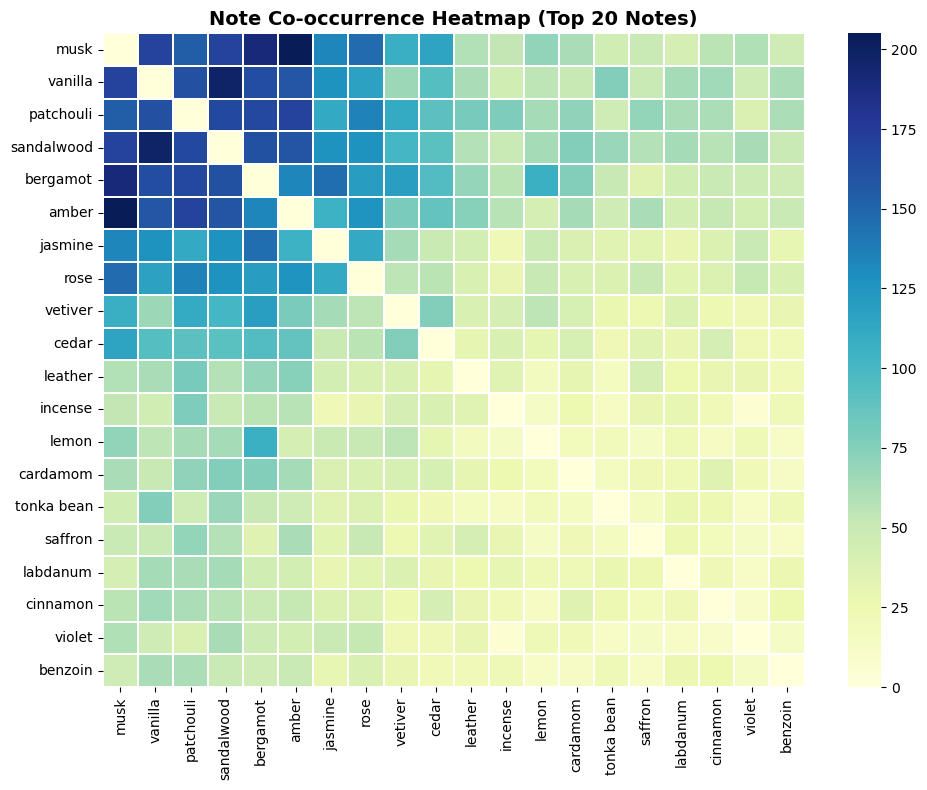

In [15]:
top_notes = [n for n, _ in note_counts.most_common(20)]
co_matrix = pd.DataFrame(0, index=top_notes, columns=top_notes, dtype=int)

for notes in all_notes:
    # keep only top notes for the co-occurrence matrix
    notes = [n for n in notes if n in top_notes]
    for a, b in itertools.combinations(set(notes), 2):
        co_matrix.loc[a, b] += 1
        co_matrix.loc[b, a] += 1

plt.figure(figsize=(10,8))
sns.heatmap(co_matrix, cmap="YlGnBu", linewidths=0.3)
plt.title("Note Co-occurrence Heatmap (Top 20 Notes)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


##  Keyword lexicons

In [18]:
SEASON_LEXICON: Dict[str, Dict[str, float]] = {
    "Summer": {
        "citrus": 2.0, "lemon": 2.0, "bergamot": 1.8, "lime": 1.5, "grapefruit": 1.8, "yuzu": 2.0,
        "aquatic": 2.2, "marine": 2.0, "sea breeze": 2.0, "ozonic": 1.8, "water": 1.0,
        "mint": 1.8, "green tea": 1.5, "fresh": 1.6, "light": 1.2, "airy": 1.2, "crisp": 1.2,
        "neroli": 1.4, "orange blossom": 1.6, "aldehydic": 1.3
    },
    "Winter": {
        "vanilla": 2.2, "tonka": 1.8, "amber": 2.0, "ambergris": 1.6, "labdanum": 1.6,
        "oud": 2.2, "agarwood": 2.2, "incense": 2.0, "smoky": 1.8, "resin": 1.6, "balsamic": 1.6,
        "leather": 2.0, "cashmere": 1.2, "gourmand": 1.8, "chocolate": 1.7, "coffee": 1.7,
        "spice": 1.6, "cinnamon": 1.8, "clove": 1.6, "cardamom": 1.5, "nutmeg": 1.5,
        "musk": 1.4, "patchouli": 1.6, "syrupy": 1.4, "dense": 1.3, "warm": 1.3
    },
    "Spring": {
        "floral": 1.8, "rose": 1.8, "jasmine": 1.8, "lily": 1.7, "tuberose": 1.5, "peony": 1.7,
        "violet": 1.5, "iris": 1.5, "muguet": 1.6, "gardenia": 1.5, "orange blossom": 1.4,
        "green": 1.6, "herbal": 1.4, "galbanum": 1.5, "dewy": 1.6, "fresh cut": 1.6, "bloom": 1.4
    },
    "Fall": {
        "woody": 1.8, "cedar": 1.7, "sandalwood": 1.8, "vetiver": 1.6, "gaïac": 1.4, "oak": 1.4,
        "tobacco": 2.0, "honey": 1.4, "amber": 1.6, "amberwood": 1.6, "boozy": 1.6,
        "spice": 1.6, "cinnamon": 1.8, "clove": 1.6, "cardamom": 1.5, "nutmeg": 1.5,
        "earthy": 1.4, "dry": 1.2, "warm": 1.2, "maple": 1.2
    },
}

GENDER_LEXICON: Dict[str, Dict[str, float]] = {
    "Men": {
        "leather": 2.0, "tobacco": 2.0, "vetiver": 1.8, "oud": 1.9, "smoke": 1.6, "incense": 1.5,
        "woody": 1.8, "spice": 1.6, "cedar": 1.6, "sandalwood": 1.6, "musk": 1.3,
        "barbershop": 1.6, "fougère": 1.6, "aromatic": 1.2, "masculine": 2.2
    },
    "Women": {
        "floral": 1.8, "rose": 1.8, "jasmine": 1.8, "peony": 1.6, "powdery": 1.6, "vanilla": 1.6,
        "fruity": 1.5, "sweet": 1.4, "white flowers": 1.6, "feminine": 2.2
    },
    "Unisex": {
        "unisex": 2.4, "shared": 2.0, "for all": 1.6, "genderless": 2.0, "neutral": 1.6,
        "fresh": 1.0, "clean": 1.0, "citrus": 1.2, "green": 1.0, "minimal": 1.0
    },
}

## Regex + scoring helpers

In [21]:
def make_pattern(word: str) -> re.Pattern:
    word = re.escape(word)
    return re.compile(rf"(?i)(?<!\w){word}(?!\w)")

SEASON_PATTERNS = {
    season: {w: (make_pattern(w), wt) for w, wt in words.items()}
    for season, words in SEASON_LEXICON.items()
}
GENDER_PATTERNS = {
    gender: {w: (make_pattern(w), wt) for w, wt in words.items()}
    for gender, words in GENDER_LEXICON.items()
}

def score_text(text: str, patterns: Dict[str, Dict[str, tuple]]) -> Dict[str, float]:
    scores = defaultdict(float)
    if not isinstance(text, str) or not text:
        return scores
    t = text.lower()
    for label, wdict in patterns.items():
        s = 0.0
        for phrase, (pat, wt) in wdict.items():
            matches = pat.findall(t)
            if matches:
                s += wt * len(matches)
        scores[label] = s
    return scores

def choose_label(scores: Dict[str, float], tie_break: List[str]):
    if not scores:
        return None, 0.0, scores
    ordered = sorted(scores.items(), key=lambda kv: kv[1], reverse=True)
    best_label, best_score = ordered[0]
    second = ordered[1][1] if len(ordered) > 1 else 0.0
    total = sum(max(v, 0.0) for _, v in ordered) + 1e-9
    conf = best_score / total if total > 0 else 0.0
    if best_score <= 0:
        best_label, conf = tie_break[0], 0.0
    return best_label, round(float(conf), 3), dict(ordered)

##  Apply scoring across rows

In [24]:
season_labels, season_conf, season_scores = [], [], []
gender_labels, gender_conf, gender_scores = [], [], []

for txt in df["text_all"].astype(str):
    s = score_text(txt, SEASON_PATTERNS)
    s_label, s_conf, s_ordered = choose_label(s, tie_break=["Summer","Spring","Fall","Winter"])
    season_labels.append(s_label); season_conf.append(s_conf); season_scores.append(s)

    g = score_text(txt, GENDER_PATTERNS)
    g_label, g_conf, g_ordered = choose_label(g, tie_break=["Unisex","Men","Women"])
    gender_labels.append(g_label); gender_conf.append(g_conf); gender_scores.append(g)

df["Predicted_Season"] = season_labels
df["Season_Confidence"] = season_conf
df["Predicted_Gender"] = gender_labels
df["Gender_Confidence"] = gender_conf

df.head(10)[["Name","Brand","Predicted_Season","Season_Confidence","Predicted_Gender","Gender_Confidence","Notes"]]

,Name,Brand,Predicted_Season,Season_Confidence,Predicted_Gender,Gender_Confidence,Notes
0,Tihota Eau de Parfum,Indult,Winter,0.871,Women,0.934,"Vanilla bean, musks"
1,Sola Parfum,Di Ser,Spring,0.643,Women,0.857,"Lavender, Yuzu, Lemongrass, Magnolia, Geranium, Jasmine, Frankincense, Myrrh"
2,Kagiroi Parfum,Di Ser,Fall,0.390,Men,0.736,"Green yuzu, green shikuwasa, sansho seed, coriander, ylang-ylang, shiso, rosewood, vetiver, hinoki, cypriol, patchouli, agarwood"
3,Velvet Fantasy Eau de Parfum,Montale,Winter,0.596,Women,0.564,"tangerine, pink pepper, black coffee, leather, violet, jasmine, lily of the valley, heliotrope powder, vanilla, amber, sandalwood, toffee, musk,..."
4,A Blvd. Called Sunset Eau de Parfum,A Lab on Fire,Winter,0.390,Men,0.470,"Bergamot, almond, violet, jasmine, leather, sandalwood, vanilla, tonka"
5,Freckled and Beautiful Eau de Parfum,A Lab on Fire,Winter,0.420,Women,0.619,"Orange flower, neroli, honeysuckle, warm milk, pastry, salicylates, sandalwood, vanilla bean, heliotrope"
6,Exit the King Eau de Parfum,Etat Libre d'Orange,Spring,0.433,Women,0.419,"Timur JE, Soap Foam Accord (Aldehydes & Musk), Pink Pepper, Jasmine e-pure, Rose Superessence, Lily-of-the-valley Accord, Patchouli, Moss Absolute, Sandalw..."
7,Eshu Extrait,PRIN,Fall,0.664,Men,0.882,"Tobacco, hay, elemi, copaiba, olibanum, nutmeg, black pepper, castoreum, atlas cedar, oakmoss, cognac, ambroxan, norlimbanol, cinnamon, cumin seed, ash"
8,Saringkarn Extrait,PRIN,Winter,0.597,Men,0.724,"Saffron, champaca, fir balsam, beeswax, amber, damask rose, rose de mai, tobacco, leather, dark chocolate, prune, oud, musk, oakmoss, ambrette, smoke, ince..."
9,Arsalan Parfum,PRIN,Winter,0.605,Men,0.774,"Cambodian oud, Trat oud, jasmin sambac, champaca, olibanum, turmeric, clove, caraway, cardamom, cinnamon, cumin, coriander, gardenia, opoponax, saffron, sa..."


## Save enriched CSV + diagnostics

In [27]:
season_scores_df = pd.DataFrame(season_scores).fillna(0.0).add_prefix("SeasonScore_")
gender_scores_df = pd.DataFrame(gender_scores).fillna(0.0).add_prefix("GenderScore_")
scores_out = pd.concat([df[["Name","Brand"]], season_scores_df, gender_scores_df], axis=1)

df.to_csv(OUT_ENRICHED, index=False)
scores_out.to_csv(OUT_SCORES, index=False)

print("Saved:", OUT_ENRICHED, "and", OUT_SCORES)

Saved: results\enriched_perfume_data.csv and results\season_gender_keyword_scores.csv


##  Quick distribution sanity-checks

In [30]:
season_counts = df["Predicted_Season"].value_counts().rename_axis("Season").reset_index(name="Count")
gender_counts = df["Predicted_Gender"].value_counts().rename_axis("Gender").reset_index(name="Count")

print("Season distribution:\n", season_counts, "\n")
print("Gender distribution:\n", gender_counts)

Season distribution:
    Season  Count
0  Winter   1156
1  Spring    430
2  Summer    316
3    Fall    289 

Gender distribution:
    Gender  Count
0     Men   1132
1   Women    904
2  Unisex    155


## simple plots 

C:\Users\jsrin\AppData\Local\Temp\ipykernel_17368\862448338.py:18: UserWarning: Glyph 127800 (\N{CHERRY BLOSSOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jsrin\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127800 (\N{CHERRY BLOSSOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


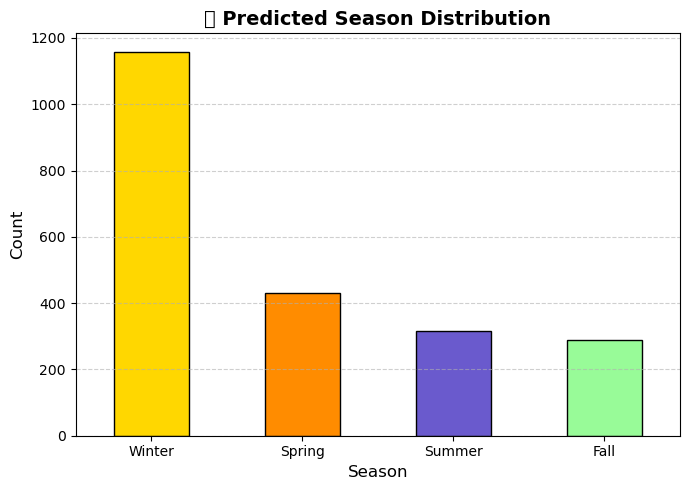

C:\Users\jsrin\AppData\Local\Temp\ipykernel_17368\862448338.py:33: UserWarning: Glyph 128107 (\N{MAN AND WOMAN HOLDING HANDS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jsrin\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128107 (\N{MAN AND WOMAN HOLDING HANDS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


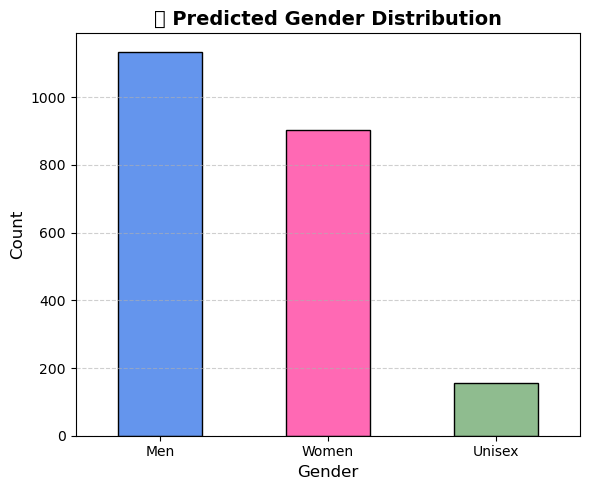

In [33]:
import matplotlib.pyplot as plt

season_colors = ['#FFD700', '#FF8C00', '#6A5ACD', '#98FB98']  
gender_colors = ['#6495ED', '#FF69B4', '#8FBC8F']  

# Plot Season Distribution
plt.figure(figsize=(7,5))
season_counts.set_index("Season")["Count"].plot(
    kind="bar",
    color=season_colors,
    edgecolor="black"
)
plt.title("🌸 Predicted Season Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Season", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Plot Gender Distribution
plt.figure(figsize=(6,5))
gender_counts.set_index("Gender")["Count"].plot(
    kind="bar",
    color=gender_colors,
    edgecolor="black"
)
plt.title("👫 Predicted Gender Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [30]:
preview_cols = ["Name","Brand","Predicted_Season","Season_Confidence","Predicted_Gender","Gender_Confidence","Notes","Description"]
df[preview_cols].head(20)

,Name,Brand,Predicted_Season,Season_Confidence,Predicted_Gender,Gender_Confidence,Notes,Description
0,Tihota Eau de Parfum,Indult,Winter,0.871,Women,0.934,"Vanilla bean, musks","Rapa Nui for sugar, Tihota is, quite simply, The One. The One that will call to you every moment you're not smelling it, The One that you've only had hints..."
1,Sola Parfum,Di Ser,Spring,0.643,Women,0.857,"Lavender, Yuzu, Lemongrass, Magnolia, Geranium, Jasmine, Frankincense, Myrrh","A tribute to the expanse of space extending from the sky to the flower and fruit laden earth below, Sola, the newest offering from DI SER and perfumer Yasu..."
2,Kagiroi Parfum,Di Ser,Fall,0.390,Men,0.736,"Green yuzu, green shikuwasa, sansho seed, coriander, ylang-ylang, shiso, rosewood, vetiver, hinoki, cypriol, patchouli, agarwood","An aromatic ode to the ancient beauty of Japan, Kagiroi represents the changes in the shade of the dawn sky over the mountains of Hokkaido, Japan. As the d..."
3,Velvet Fantasy Eau de Parfum,Montale,Winter,0.596,Women,0.564,"tangerine, pink pepper, black coffee, leather, violet, jasmine, lily of the valley, heliotrope powder, vanilla, amber, sandalwood, toffee, musk,...","Velvet Fantasy is a solar fragrance where citrus and velvety fruits mingle with the elegance of rose and the gourmand femininity of violet. Thereafter, inc..."
4,A Blvd. Called Sunset Eau de Parfum,A Lab on Fire,Winter,0.390,Men,0.470,"Bergamot, almond, violet, jasmine, leather, sandalwood, vanilla, tonka","There's no way A Lab On Fire could relocate to Los Angeles and not pay tribute to L.A.'s most iconic Boulevard, home to the legendary neon-drenched rock st..."
5,Freckled and Beautiful Eau de Parfum,A Lab on Fire,Winter,0.420,Women,0.619,"Orange flower, neroli, honeysuckle, warm milk, pastry, salicylates, sandalwood, vanilla bean, heliotrope","There's no beauty quite like being young in the City of Angels- the wind in your hair, the sand between your toes, the endless possibilities for freedom an..."
6,Exit the King Eau de Parfum,Etat Libre d'Orange,Spring,0.433,Women,0.419,"Timur JE, Soap Foam Accord (Aldehydes & Musk), Pink Pepper, Jasmine e-pure, Rose Superessence, Lily-of-the-valley Accord, Patchouli, Moss Absolute, Sandalw...","In these tumultuous times, a fragrance that celebrates destruction and dethronement might seem... risky. But Etat Libre was never about playing it safe, an..."
7,Eshu Extrait,PRIN,Fall,0.664,Men,0.882,"Tobacco, hay, elemi, copaiba, olibanum, nutmeg, black pepper, castoreum, atlas cedar, oakmoss, cognac, ambroxan, norlimbanol, cinnamon, cumin seed, ash","Eshu, the mischievous god of Yoruba legend, who translates between the gods and all the peoples of earth. Eshu, a groundbreaking 2000 Fall/Autumn collectio..."
8,Saringkarn Extrait,PRIN,Winter,0.597,Men,0.724,"Saffron, champaca, fir balsam, beeswax, amber, damask rose, rose de mai, tobacco, leather, dark chocolate, prune, oud, musk, oakmoss, ambrette, smoke, ince...","A taste of love and seduction. The value of love between lover, friend and family and humanity. A taste of happiness. Saringkarn, a tribute to the traditio..."
9,Arsalan Parfum,PRIN,Winter,0.605,Men,0.774,"Cambodian oud, Trat oud, jasmin sambac, champaca, olibanum, turmeric, clove, caraway, cardamom, cinnamon, cumin, coriander, gardenia, opoponax, saffron, sa...",The Persian legend of Arsalan is a story of a royal heir who rediscovers his hidden heritage and decides to reclaim his throne. And as would befit a fragra...
